In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, roc_curve, precision_recall_curve, f1_score, accuracy_score


import shap
from sklearn.inspection import PartialDependenceDisplay
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

In [3]:
!pip install -U scikit-learn imbalanced-learn

In [4]:
!pip install shap

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
data = pd.read_csv('/kaggle/input/datasets/praveenaradha/smart-meter-dataset/smart_meter_data.csv')
data.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [7]:
print(data.shape)

(5000, 7)


In [8]:
print(data.isnull().sum())

Timestamp               0
Electricity_Consumed    0
Temperature             0
Humidity                0
Wind_Speed              0
Avg_Past_Consumption    0
Anomaly_Label           0
dtype: int64


In [9]:
print(any(data.duplicated()))

False


In [10]:
data['Anomaly'] = data.Anomaly_Label.map({'Normal': 0, 'Abnormal': 1})

print(data.Anomaly.value_counts())

data_copy_1 = data.drop(['Anomaly_Label'], axis=1)
data_copy_1.sample(5, random_state=42)

Anomaly
0    4750
1     250
Name: count, dtype: int64


,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly
1501,2024-02-01 06:30:00,0.283136,0.363988,0.557851,0.574558,0.850957,1
2586,2024-02-23 21:00:00,0.155125,0.386928,0.704744,0.365213,0.651421,0
2653,2024-02-25 06:30:00,0.546763,0.591185,0.552238,0.302088,0.426179,0
1055,2024-01-22 23:30:00,0.263063,0.727734,0.386598,0.398739,0.513191,0
705,2024-01-15 16:30:00,0.476002,0.246476,0.392256,0.629530,0.323443,0


In [11]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data = data.sort_values('Timestamp')

data['hour'] = data['Timestamp'].dt.hour
data['day'] = data['Timestamp'].dt.day
data['weekday'] = data['Timestamp'].dt.weekday
data['month'] = data['Timestamp'].dt.month

In [12]:
data['Monthly_Mean'] = data.groupby('month')['Electricity_Consumed'].transform('mean')
data['Monthly_STD'] = data.groupby('month')['Electricity_Consumed'].transform('std')

data['Seasonal_Anomaly'] = (
    data['Electricity_Consumed'] > (data['Monthly_Mean'] + 2 * data['Monthly_STD'])
).astype(int)

In [13]:
data['Seasonal_Anomaly'].value_counts()

Seasonal_Anomaly
0    4883
1     117
Name: count, dtype: int64

In [14]:
def convert(hour: int) -> str:
    if 0 <= hour < 6:
        return 'Late_Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Night'
    else:
        return 'NAN'

data['Day_Part'] = data['hour'].apply(convert)

print(data['Day_Part'].value_counts())

Day_Part
Late_Night    1256
Morning       1248
Afternoon     1248
Night         1248
Name: count, dtype: int64


In [15]:
data = pd.get_dummies(data, columns=['Day_Part'], drop_first=True)

In [16]:
print(data.columns)

Index(['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity',
       'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label', 'Anomaly',
       'hour', 'day', 'weekday', 'month', 'Monthly_Mean', 'Monthly_STD',
       'Seasonal_Anomaly', 'Day_Part_Late_Night', 'Day_Part_Morning',
       'Day_Part_Night'],
      dtype='object')


In [17]:
X = data.drop([
    'Timestamp',
    'Anomaly',
    'Anomaly_Label',
    'Seasonal_Anomaly'
], axis=1)

y = data['Anomaly']

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (5000, 14)
Target distribution:
 Anomaly
0    4750
1     250
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
smt = SMOTETomek(random_state=42)

X_train_resampled, y_train_resampled = smt.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTETomek balancing:")
print(pd.Series(y_train_resampled).value_counts())

After SMOTETomek balancing:
Anomaly
0    3799
1    3799
Name: count, dtype: int64


Random Forest:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.73      0.76      0.75        50

    accuracy                           0.97      1000
   macro avg       0.86      0.87      0.87      1000
weighted avg       0.97      0.97      0.97      1000

XGBoost:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       950
           1       0.73      0.98      0.84        50

    accuracy                           0.98      1000
   macro avg       0.87      0.98      0.91      1000
weighted avg       0.99      0.98      0.98      1000

Logistic Regression:
               precision    recall  f1-score   support

           0       0.95      0.59      0.72       950
           1       0.04      0.36      0.08        50

    accuracy                           0.57      1000
   macro avg       0.49      0.47      0.40      1000
weighted avg       0.90   

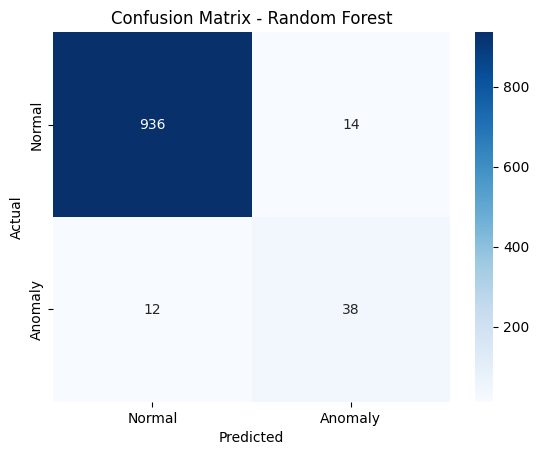

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))

svm = SVC(kernel='rbf')
svm.fit(X_train_resampled, y_train_resampled)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM:\n", classification_report(y_test, y_pred_svm))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)
y_pred_knn = knn.predict(X_test_scaled)
print("KNN:\n", classification_report(y_test, y_pred_knn))

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_resampled, y_train_resampled)
y_pred_dt = dt.predict(X_test_scaled)
print("Decision Tree:\n", classification_report(y_test, y_pred_dt))

nb = GaussianNB()
nb.fit(X_train_resampled, y_train_resampled)
y_pred_nb = nb.predict(X_test_scaled)
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

iso = IsolationForest(contamination=0.5, random_state=42)
iso.fit(X_train_resampled)
y_pred_iso = iso.predict(X_test_scaled)
y_pred_iso = [1 if p == -1 else 0 for p in y_pred_iso]
print("Isolation Forest:\n", classification_report(y_test, y_pred_iso))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
print(classification_report(y_test, y_pred_rf))

probs = rf.predict_proba(X_test_scaled)[:,1]
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.73      0.76      0.75        50

    accuracy                           0.97      1000
   macro avg       0.86      0.87      0.87      1000
weighted avg       0.97      0.97      0.97      1000

ROC AUC: 0.9865263157894737


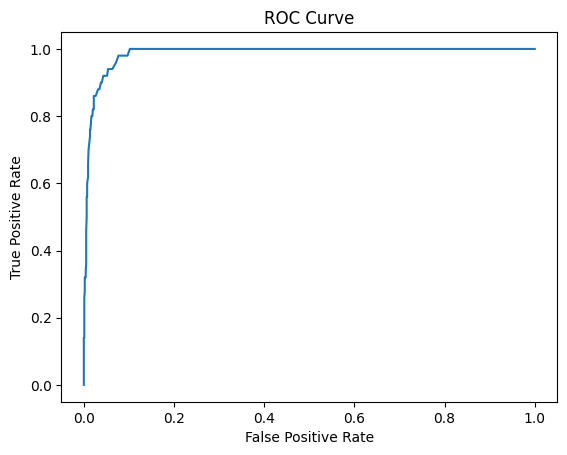

In [24]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

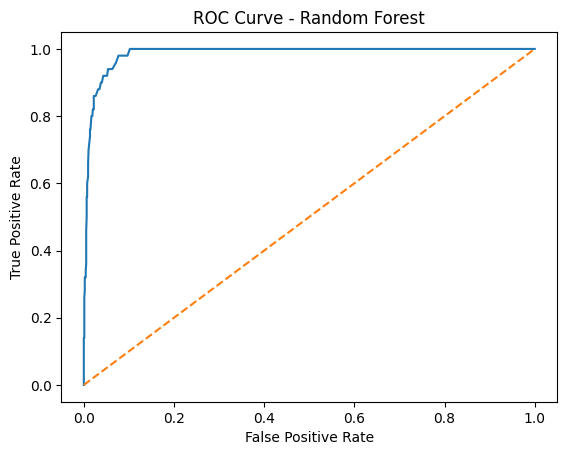

In [25]:
probs = rf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

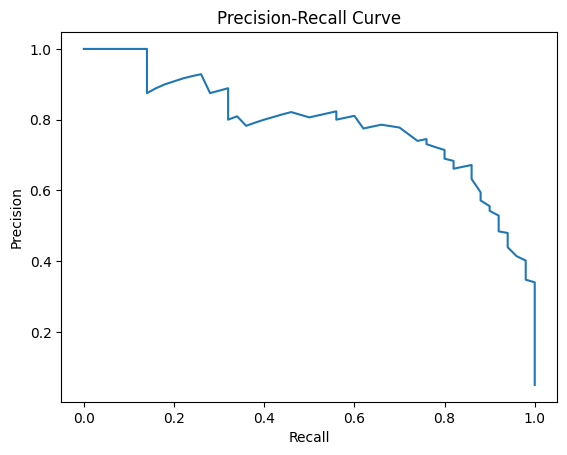

In [26]:
precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

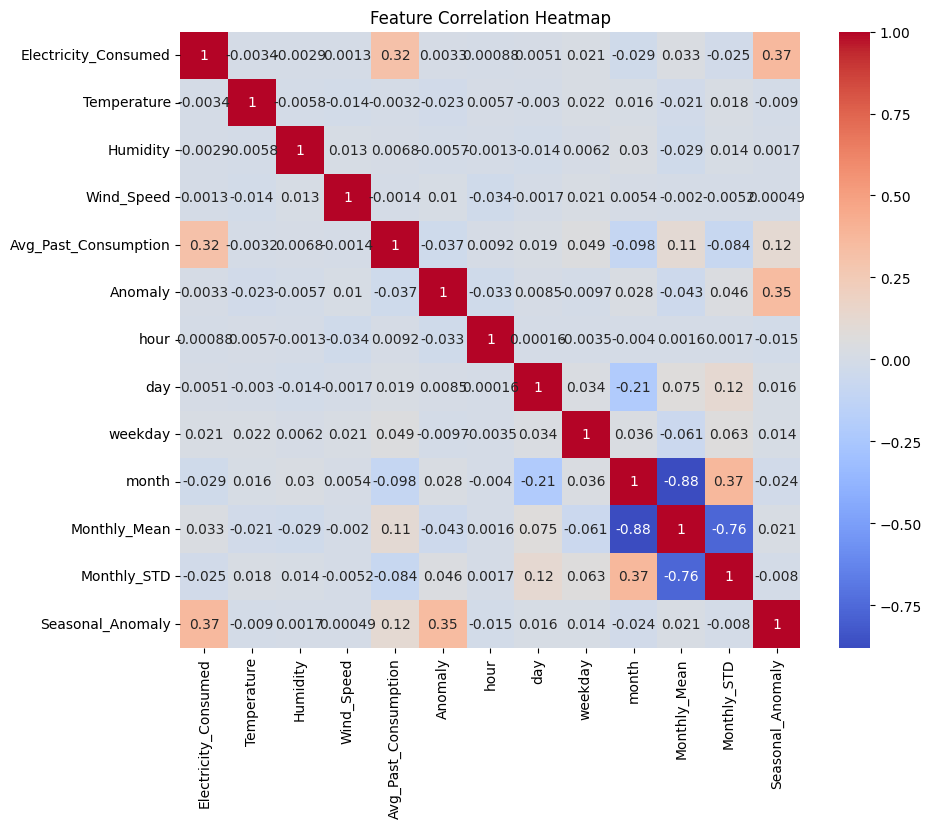

In [27]:
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

Electricity Consumption Pattern by Hour

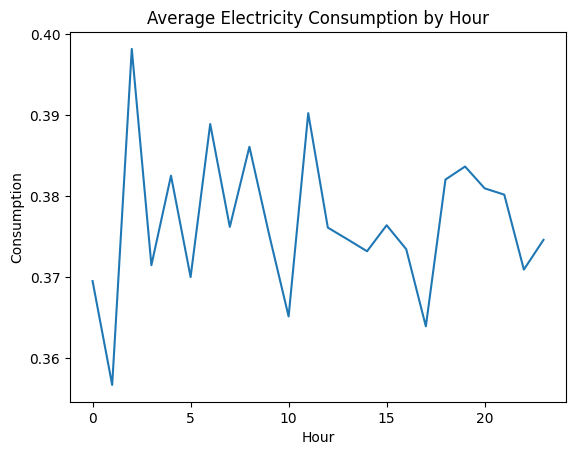

In [28]:
data.groupby("hour")["Electricity_Consumed"].mean().plot()
plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.show()

Anomaly Distribution Visualization

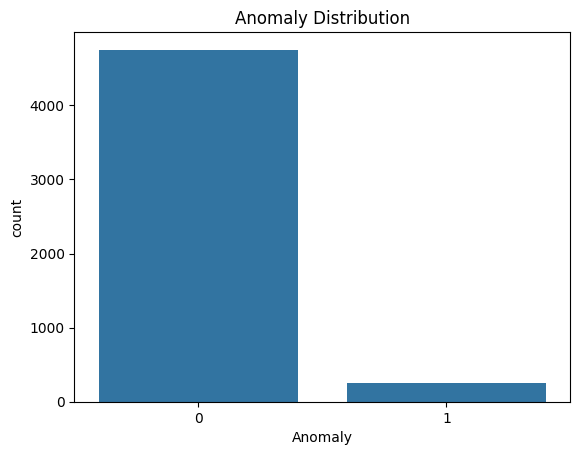

In [29]:
sns.countplot(x=data["Anomaly"])
plt.title("Anomaly Distribution")
plt.show()


SHAP (Global and Local Explainability)

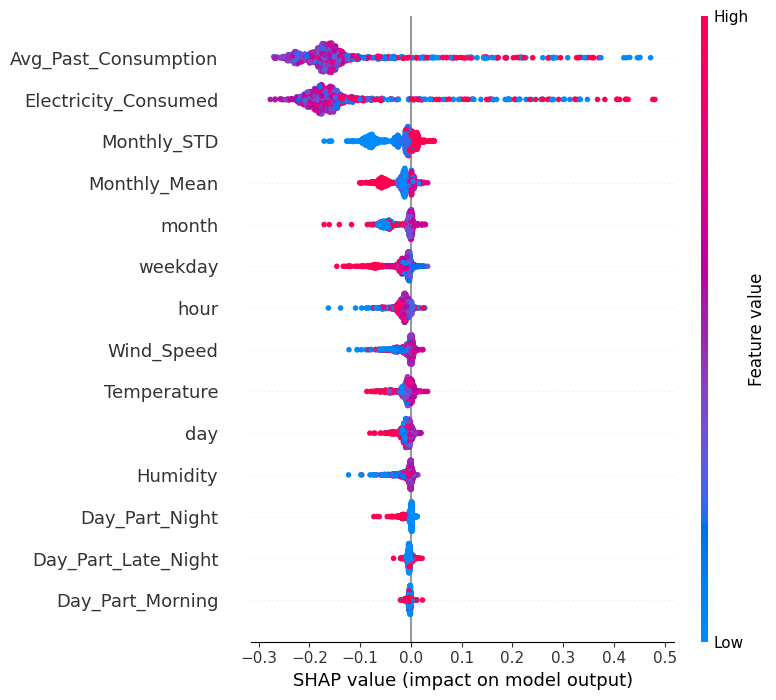

In [30]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_scaled_df)
sv = shap_values[:, :, 1]

shap.summary_plot(sv, X_test_scaled_df)


Explain One Prediction

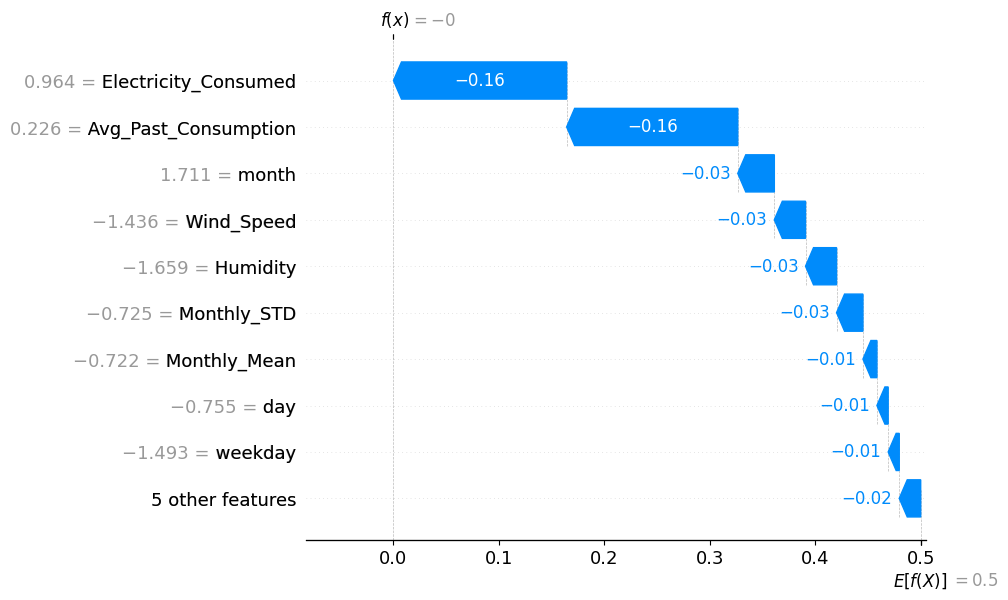

In [31]:
shap.plots.waterfall(
    shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value[1],
        data=X_test_scaled_df.iloc[0],
        feature_names=X.columns
    )
)

SHAP Dependence Plot (Advanced Explainability)

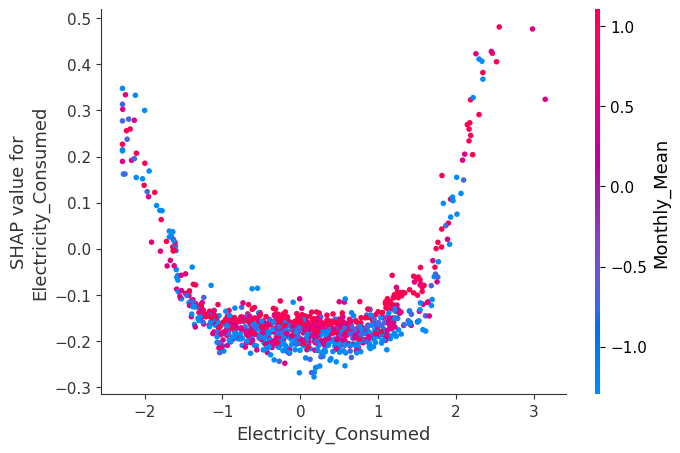

In [32]:
shap.dependence_plot("Electricity_Consumed", sv, X_test_scaled_df)

Feature Importance Ranking

Time Series Visualization

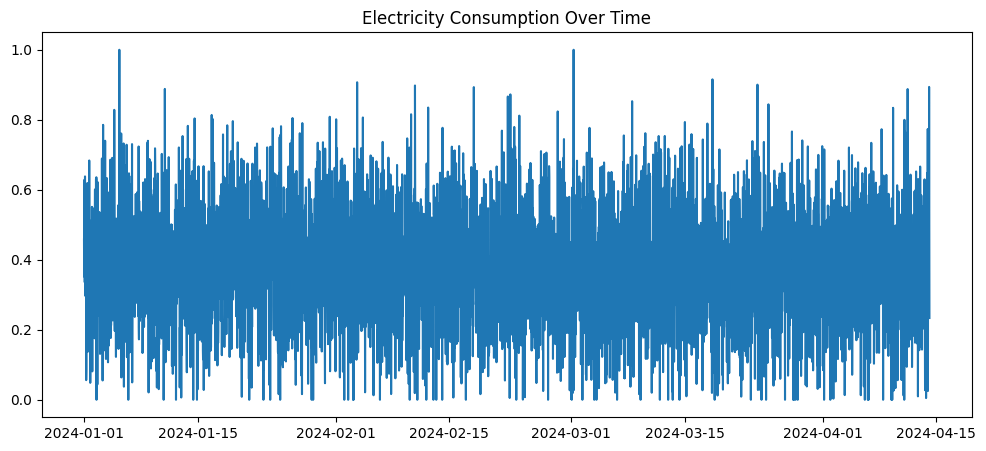

In [33]:
plt.figure(figsize=(12,5))
plt.plot(data["Timestamp"], data["Electricity_Consumed"])
plt.title("Electricity Consumption Over Time")
plt.show()

Decision Tree Visualization

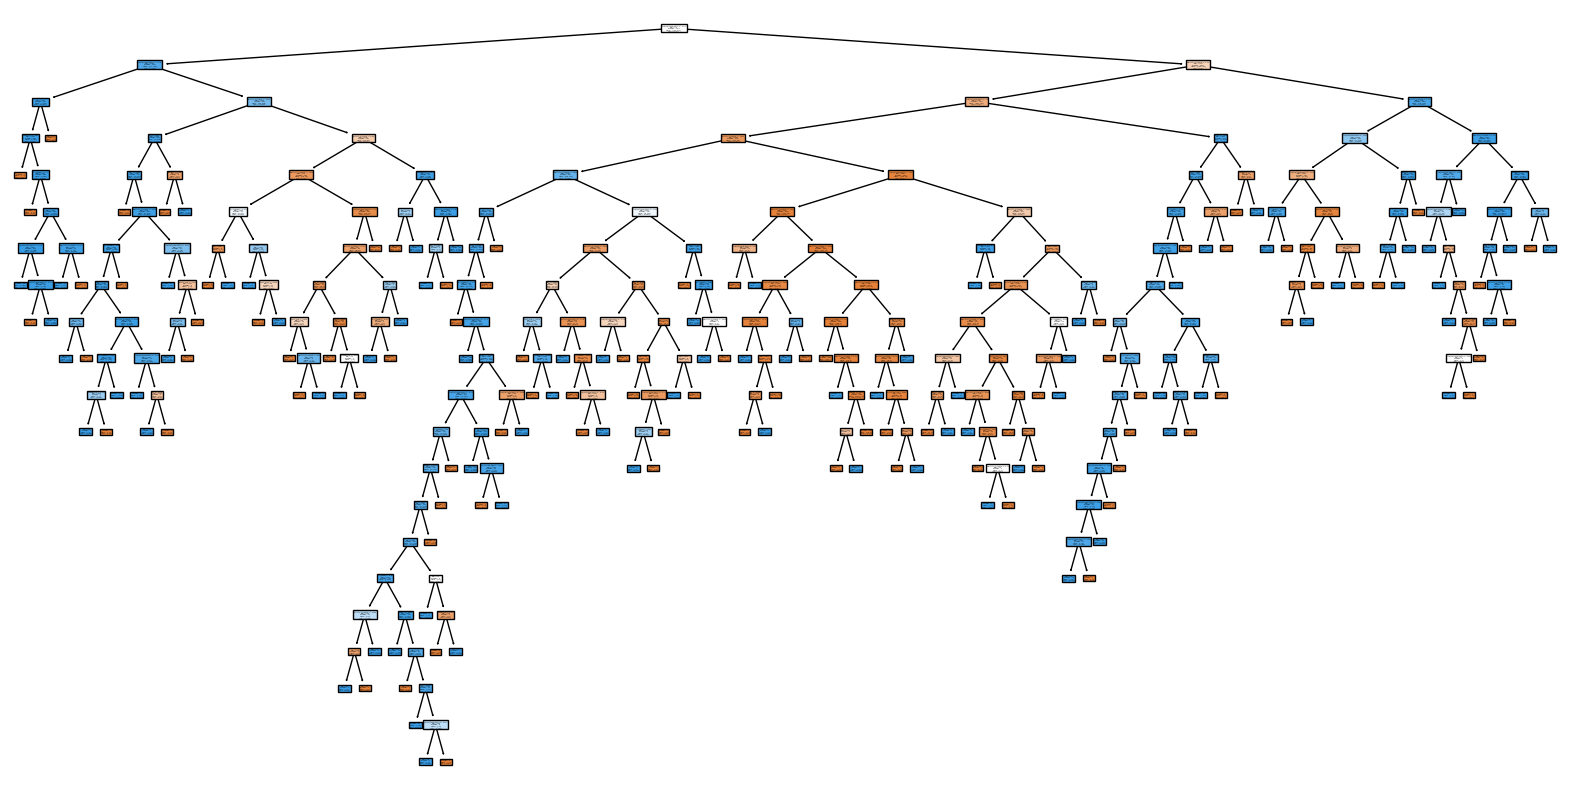

In [34]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=["Normal","Anomaly"], filled=True)
plt.show()

Feature Importance

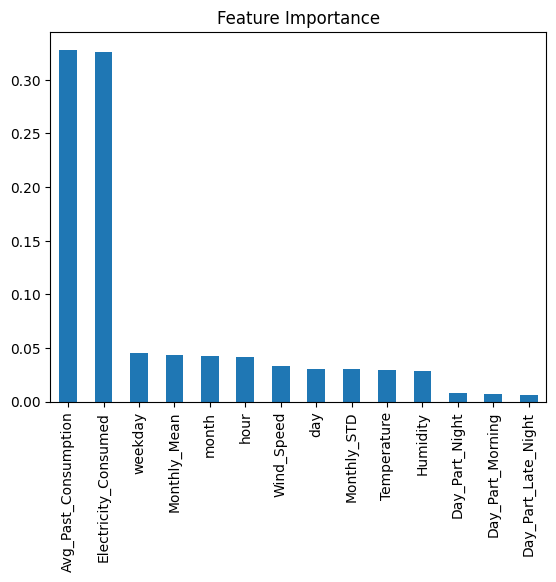

In [35]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

LSTM, ATTENTION

Create Sequences

In [36]:
def create_sequences(X, y, window_size=24):
    X_seq = []
    y_seq = []

    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_train_resampled, y_train_resampled, window_size=24)

print("Sequence shape:", X_seq.shape)
print("Labels shape:", y_seq.shape)

Sequence shape: (7574, 24, 14)
Labels shape: (7574,)


BiLSTM and Attention Layer

In [37]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

2026-04-07 13:40:58.530360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775569258.556844     216 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775569258.565459     216 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775569258.585948     216 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775569258.585985     216 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775569258.585988     216 computation_placer.cc:177] computation placer alr

In [38]:
class Attention(Layer):

    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[1],1),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):

        e = K.tanh(K.dot(x,self.W)+self.b)

        a = K.softmax(e,axis=1)

        output = x*a

        return K.sum(output,axis=1)

Build BiLSTM and Attention Model

In [39]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model

timesteps = X_seq.shape[1]
features = X_seq.shape[2]

inputs = Input(shape=(timesteps,features))

bilstm = Bidirectional(
    LSTM(64, return_sequences=True)
)(inputs)

attention = Attention()(bilstm)

dense1 = Dense(32, activation="relu")(attention)

dropout = Dropout(0.3)(dense1)

outputs = Dense(1, activation="sigmoid")(dropout)

bilstm_att_model = Model(inputs,outputs)

bilstm_att_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_att_model.summary()

I0000 00:00:1775569281.183683     216 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,761 (174.85 KB)

 Trainable params: 44,761 (174.85 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = bilstm_att_model.fit(
    X_seq,
    y_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10


I0000 00:00:1775569286.276356     296 cuda_dnn.cc:529] Loaded cuDNN version 91002


95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8465 - loss: 0.4578 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9632 - loss: 0.1453 - val_accuracy: 1.0000 - val_loss: 3.4144e-04
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9644 - loss: 0.1432 - val_accuracy: 1.0000 - val_loss: 7.5136e-04
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9684 - loss: 0.1320 - val_accuracy: 0.9993 - val_loss: 0.0019
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9688 - loss: 0.1244 - val_accuracy: 1.0000 - val_loss: 1.1180e-05
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9705 - loss: 0.1183 - val_accuracy: 1.0000 - val_loss: 1.6035e-04
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9647 - loss: 0.1327 - val_accuracy: 1.0000 - val_loss: 6.7934e-04
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9651 - loss: 0.1340 - val_accuracy: 1

Extract Embeddings

In [41]:
feature_extractor = Model(
    inputs=bilstm_att_model.input,
    outputs=dense1
)

X_embeddings = feature_extractor.predict(X_seq)

print("Embedding shape:", X_embeddings.shape)

237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Embedding shape: (7574, 32)


In [42]:
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

rf_hybrid = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_hybrid.fit(X_train_emb,y_train_emb)

y_pred_hybrid = rf_hybrid.predict(X_test_emb)

print(classification_report(y_test_emb,y_pred_hybrid))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       755
           1       1.00      0.95      0.97       760

    accuracy                           0.97      1515
   macro avg       0.98      0.97      0.97      1515
weighted avg       0.98      0.97      0.97      1515



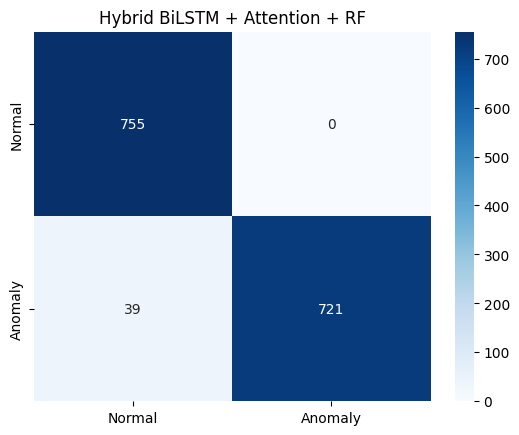

In [43]:
cm = confusion_matrix(y_test_emb,y_pred_hybrid)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Anomaly"],
    yticklabels=["Normal","Anomaly"]
)

plt.title("Hybrid BiLSTM + Attention + RF")
plt.show()

Attention Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


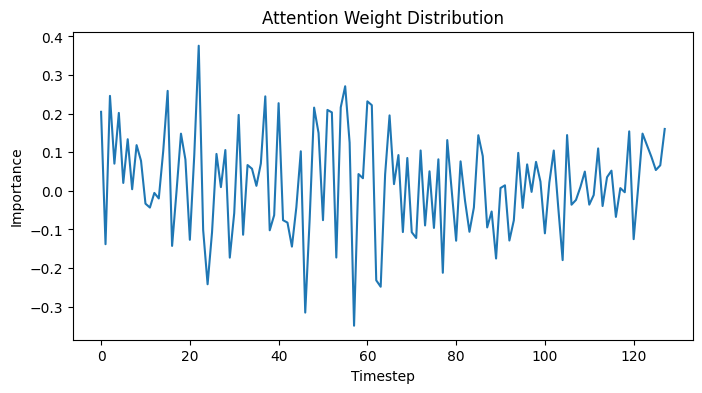

In [44]:
attention_layer = bilstm_att_model.layers[2]

attention_model = tf.keras.Model(
    inputs=bilstm_att_model.input,
    outputs=attention_layer.output
)

attention_output = attention_model.predict(X_seq[:1])

plt.figure(figsize=(8,4))
plt.plot(attention_output.flatten())
plt.title("Attention Weight Distribution")
plt.xlabel("Timestep")
plt.ylabel("Importance")
plt.show()

Feature Importance

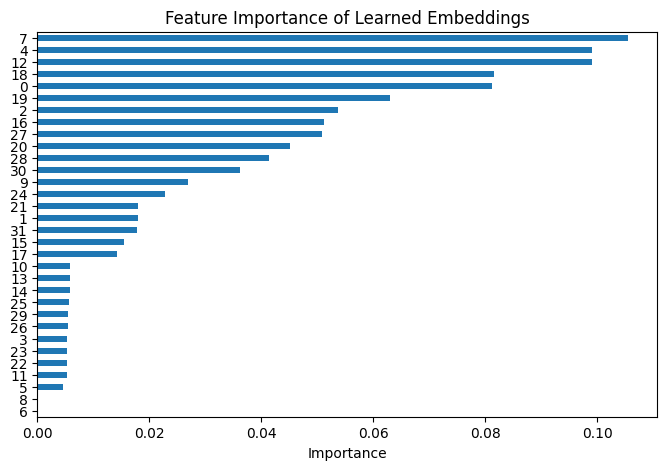

In [45]:
importances = rf_hybrid.feature_importances_

feat_imp = pd.Series(importances)

plt.figure(figsize=(8,5))
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance of Learned Embeddings")
plt.xlabel("Importance")
plt.show()

SHAP for Hybrid Model

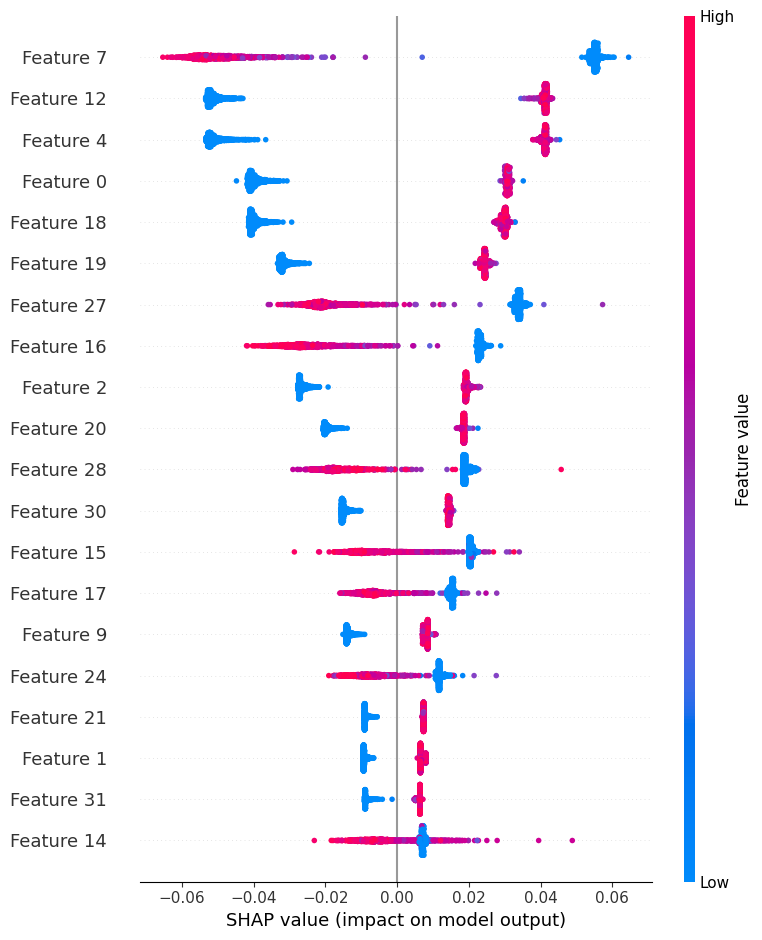

In [46]:
explainer = shap.TreeExplainer(rf_hybrid)

shap_values = explainer.shap_values(X_test_emb)
sv = shap_values[:, :, 1]
shap.summary_plot(sv, X_test_emb)

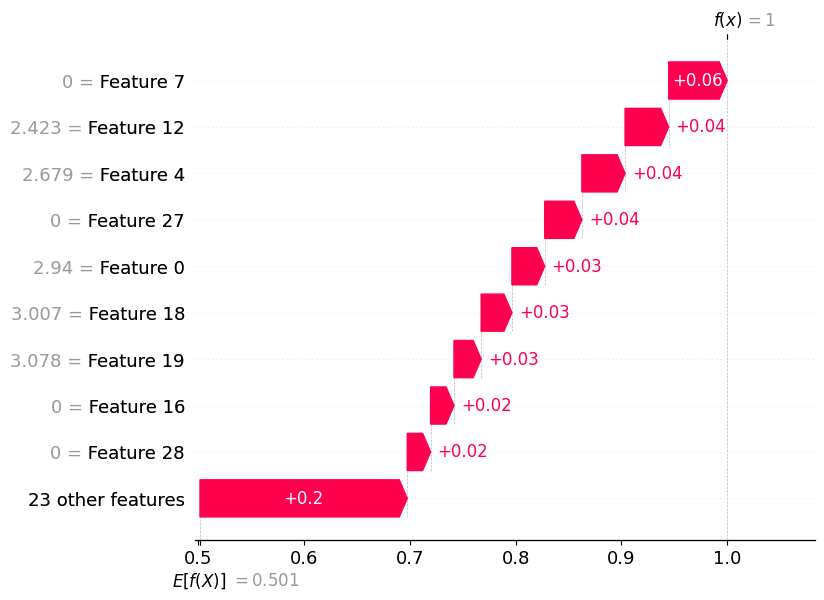

In [47]:
shap.plots.waterfall(
    shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value[1],
        data=X_test_emb[0]
    )
)

SHAP Dependence & Interaction Plots

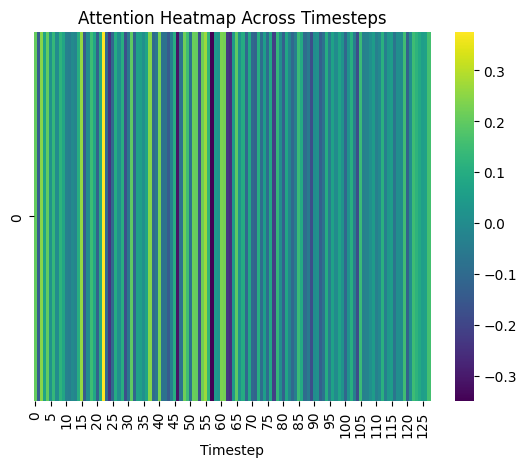

In [48]:
attention_weights = attention_output.reshape(1,-1)

sns.heatmap(attention_weights, cmap="viridis")
plt.title("Attention Heatmap Across Timesteps")
plt.xlabel("Timestep")
plt.show()

Partial Dependence Plots (Model Behavior)

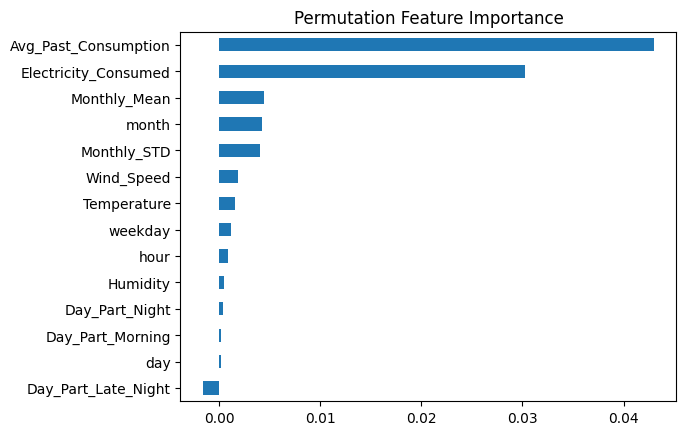

In [49]:
result = permutation_importance(
    rf,
    X_test_scaled,
    y_test,
    n_repeats=10
)

importances = pd.Series(result.importances_mean, index=X.columns)

importances.sort_values().plot(kind="barh")
plt.title("Permutation Feature Importance")
plt.show()

Time-Series Anomaly Visualization

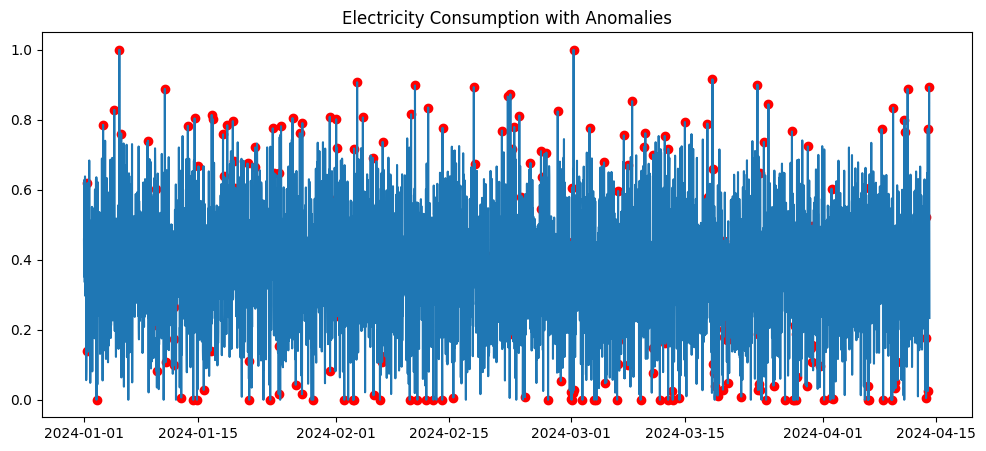

In [50]:
plt.figure(figsize=(12,5))
plt.plot(data["Timestamp"], data["Electricity_Consumed"])

anomalies = data[data["Anomaly"]==1]

plt.scatter(anomalies["Timestamp"], anomalies["Electricity_Consumed"], color="red")
plt.title("Electricity Consumption with Anomalies")
plt.show()

LIME EXPLANATIONS

In [51]:
# 1a. LIME for Random Forest

lime_explainer_rf = LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=list(X.columns),
    class_names=["Normal", "Anomaly"],
    mode="classification",
    random_state=42
)

Text(0.5, 0, 'LIME Weight')

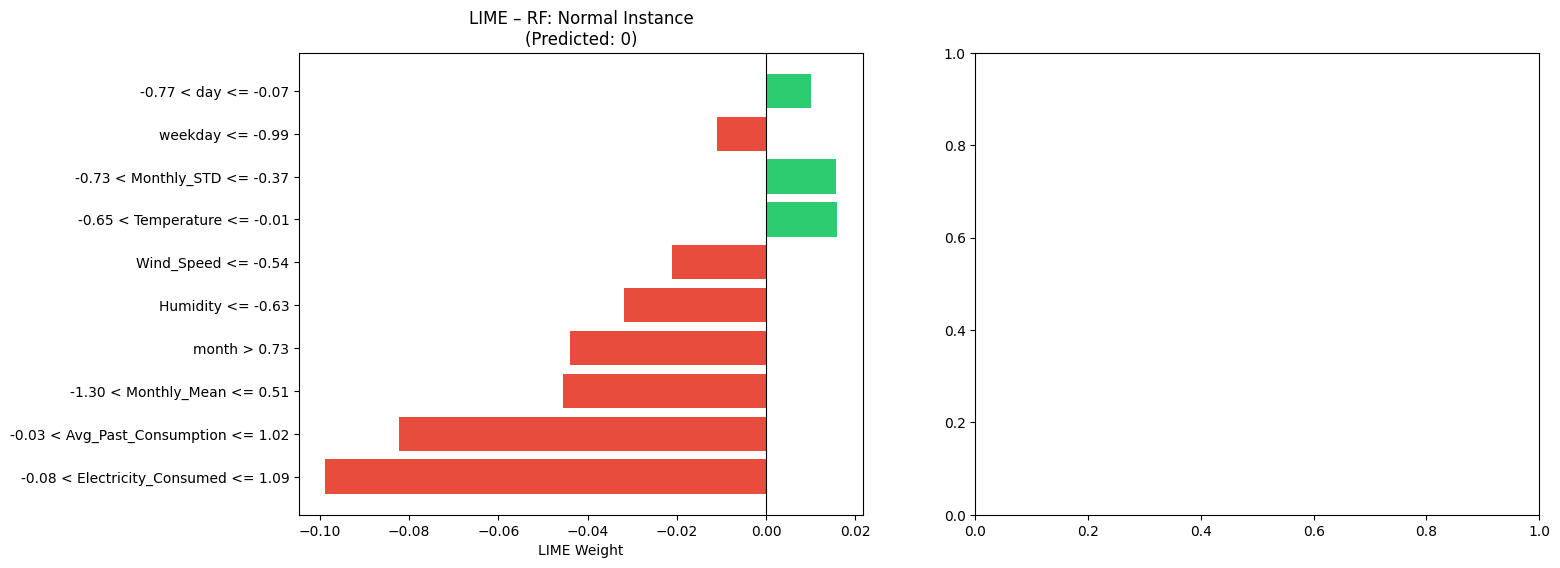

In [52]:
# Explain one NORMAL instance
normal_idx = np.where(y_test.values == 0)[0][0]
exp_normal = lime_explainer_rf.explain_instance(
    data_row=X_test_scaled[normal_idx],
    predict_fn=rf.predict_proba,
    num_features=10
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normal explanation
ax = axes[0]
exp_normal_list = exp_normal.as_list()
features_n = [x[0] for x in exp_normal_list]
weights_n  = [x[1] for x in exp_normal_list]
colors_n   = ["#2ecc71" if w > 0 else "#e74c3c" for w in weights_n]
ax.barh(features_n, weights_n, color=colors_n)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LIME – RF: Normal Instance\n(Predicted: {rf.predict(X_test_scaled[normal_idx:normal_idx+1])[0]})", fontsize=12)
ax.set_xlabel("LIME Weight")

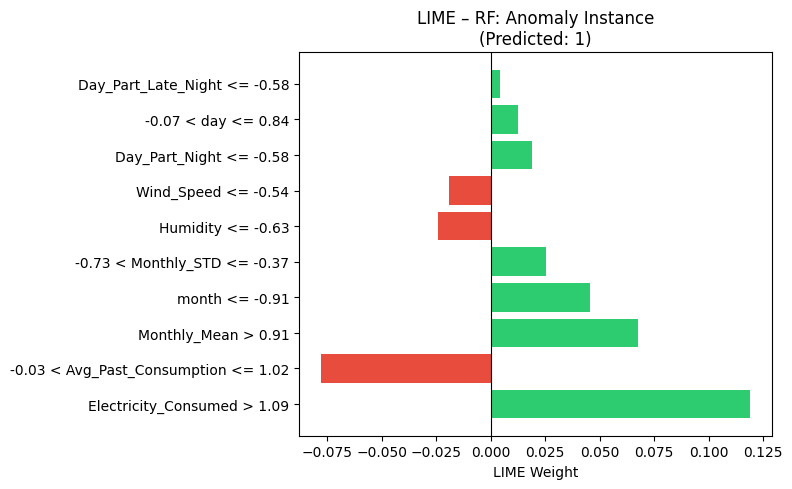

LIME RF: Green = pushes toward Anomaly | Red = pushes toward Normal


In [53]:
y_test_arr = np.array(y_test)
anomaly_indices = np.where(y_test_arr == 1)[0]

if len(anomaly_indices) == 0:
    print("No anomaly found in test set")
else:
    anomaly_idx = anomaly_indices[0]

    exp_anomaly = lime_explainer_rf.explain_instance(
        data_row=X_test_scaled[anomaly_idx],
        predict_fn=rf.predict_proba,
        num_features=10
    )

    exp_anomaly_list = exp_anomaly.as_list()

    features_a = [x[0] for x in exp_anomaly_list]
    weights_a  = [x[1] for x in exp_anomaly_list]
    colors_a   = ["#2ecc71" if w > 0 else "#e74c3c" for w in weights_a]

    plt.figure(figsize=(8,5))
    plt.barh(features_a, weights_a, color=colors_a)
    plt.axvline(0, color="black", linewidth=0.8)

    pred = rf.predict(X_test_scaled[anomaly_idx:anomaly_idx+1])[0]
    plt.title(f"LIME – RF: Anomaly Instance\n(Predicted: {pred})")
    plt.xlabel("LIME Weight")

    plt.tight_layout()
    plt.show()

    print("LIME RF: Green = pushes toward Anomaly | Red = pushes toward Normal")

In [54]:
#1b. LIME for Hybrid BiLSTM+RF
lime_explainer_hybrid = LimeTabularExplainer(
    training_data=X_train_emb,
    feature_names=[f"Embedding_{i}" for i in range(X_train_emb.shape[1])],
    class_names=["Normal", "Anomaly"],
    mode="classification",
    random_state=42
)

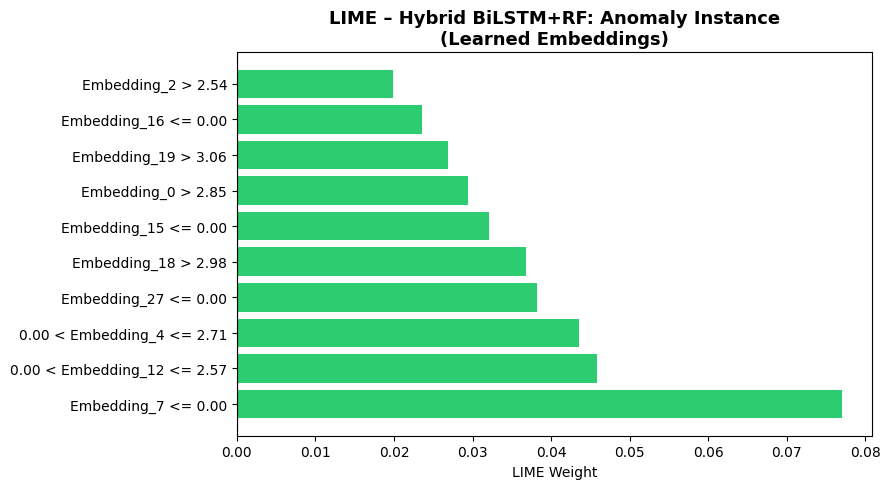

In [55]:
# Anomaly instance in hybrid model
hybrid_anomaly_idx = np.where(y_test_emb == 1)[0][0]
exp_hybrid = lime_explainer_hybrid.explain_instance(
    data_row=X_test_emb[hybrid_anomaly_idx],
    predict_fn=rf_hybrid.predict_proba,
    num_features=10
)

plt.figure(figsize=(9, 5))
exp_hybrid_list = exp_hybrid.as_list()
feats_h  = [x[0] for x in exp_hybrid_list]
wghts_h  = [x[1] for x in exp_hybrid_list]
colors_h = ["#2ecc71" if w > 0 else "#e74c3c" for w in wghts_h]
plt.barh(feats_h, wghts_h, color=colors_h)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("LIME – Hybrid BiLSTM+RF: Anomaly Instance\n(Learned Embeddings)", fontsize=13, fontweight="bold")
plt.xlabel("LIME Weight")
plt.tight_layout()
plt.savefig("lime_hybrid_explanations.png", dpi=150, bbox_inches="tight")
plt.show()


LIME Stability: Comparing explanations for 10 anomaly instances

LIME weight variance across 10 anomaly instances:
Electricity_Consumed > 1.09             0.063808
-0.08 < Electricity_Consumed <= 1.09    0.047733
Monthly_Mean > 0.91                     0.039428
-0.03 < Avg_Past_Consumption <= 1.02    0.039391
-0.24 < month <= 0.73                   0.029316
dtype: float64


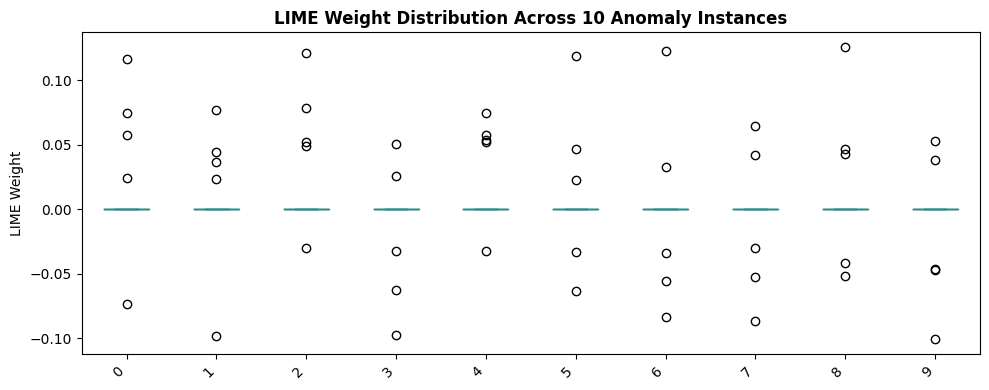

In [56]:
# 1c. LIME Stability Check (10 similar instances)
print("\nLIME Stability: Comparing explanations for 10 anomaly instances")
anomaly_indices = np.where(y_test.values == 1)[0][:10]
all_lime_weights = []

for idx in anomaly_indices:
    exp = lime_explainer_rf.explain_instance(
        data_row=X_test_scaled[idx],
        predict_fn=rf.predict_proba,
        num_features=5
    )
    weights_dict = dict(exp.as_list())
    all_lime_weights.append(weights_dict)

lime_df = pd.DataFrame(all_lime_weights).fillna(0)
print("\nLIME weight variance across 10 anomaly instances:")
print(lime_df.std().sort_values(ascending=False).head(5))

plt.figure(figsize=(10, 4))
lime_df.T.plot(kind="box", ax=plt.gca())
plt.title("LIME Weight Distribution Across 10 Anomaly Instances", fontweight="bold")
plt.ylabel("LIME Weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("lime_stability.png", dpi=150, bbox_inches="tight")
plt.show()

PARTIAL DEPENDENCE PLOTS (PDP) + ICE

Plotting PDP + ICE for top features: ['Avg_Past_Consumption', 'Electricity_Consumed', 'weekday', 'Monthly_Mean']


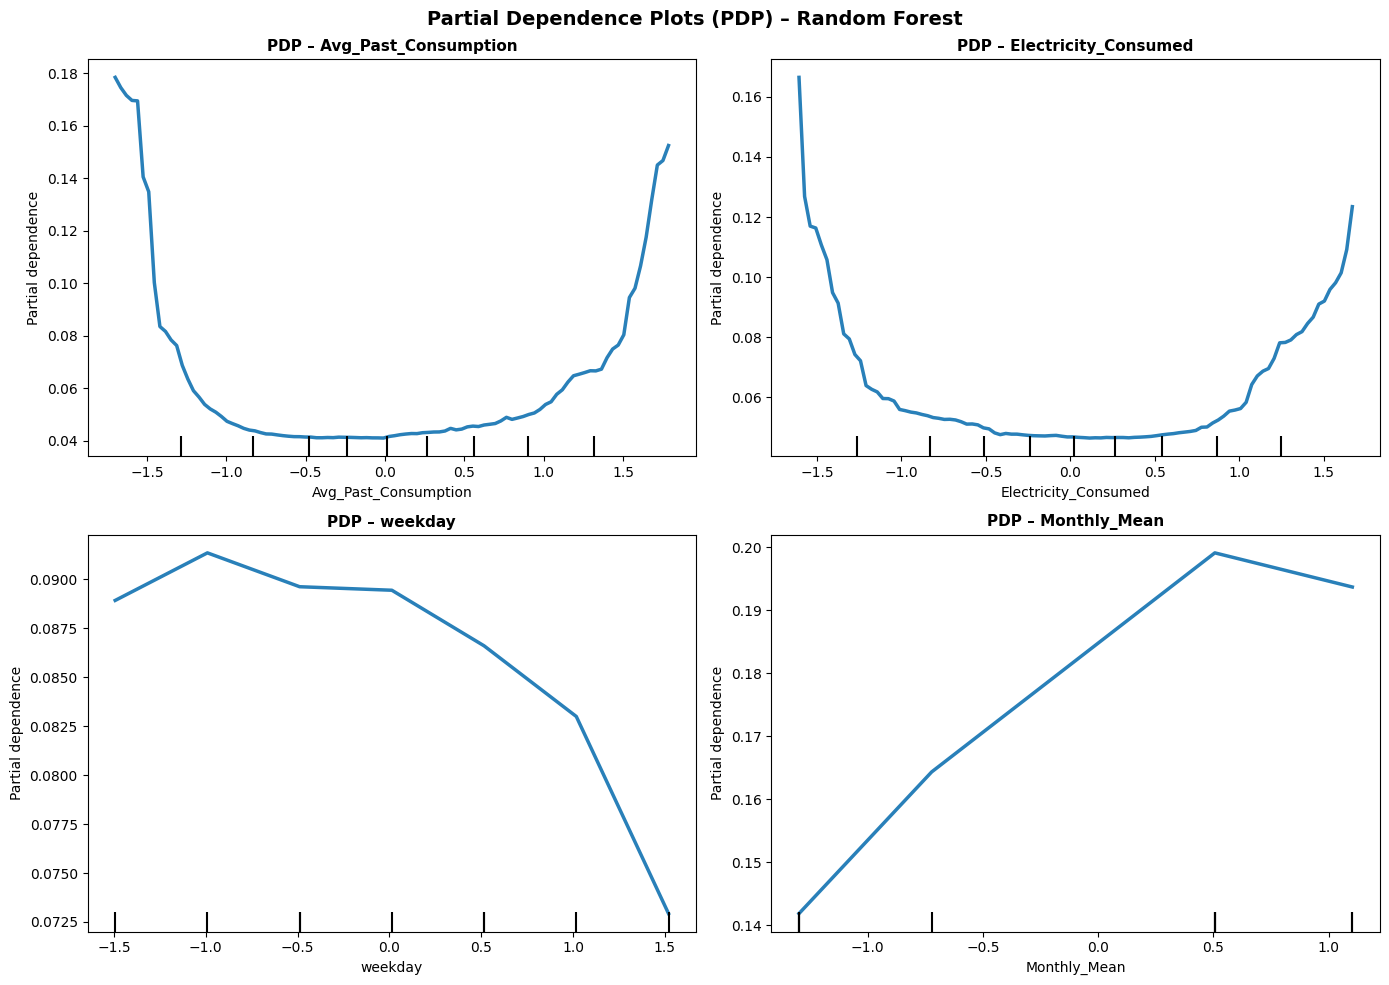

In [57]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Top features from SHAP/RF importance
top_features = list(
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(4)
    .index
)
print(f"Plotting PDP + ICE for top features: {top_features}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = list(X.columns).index(feat)
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test_scaled_df,
        features=[feat_idx],
        feature_names=list(X.columns),
        kind="average",         # PDP only
        ax=axes[i],
        line_kw={"color": "#2980b9", "linewidth": 2.5},
    )
    axes[i].set_title(f"PDP – {feat}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Anomaly Probability")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Partial Dependence Plots (PDP) – Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pdp_plots.png", dpi=150, bbox_inches="tight")
plt.show()


ICE Plots (Individual Conditional Expectation)

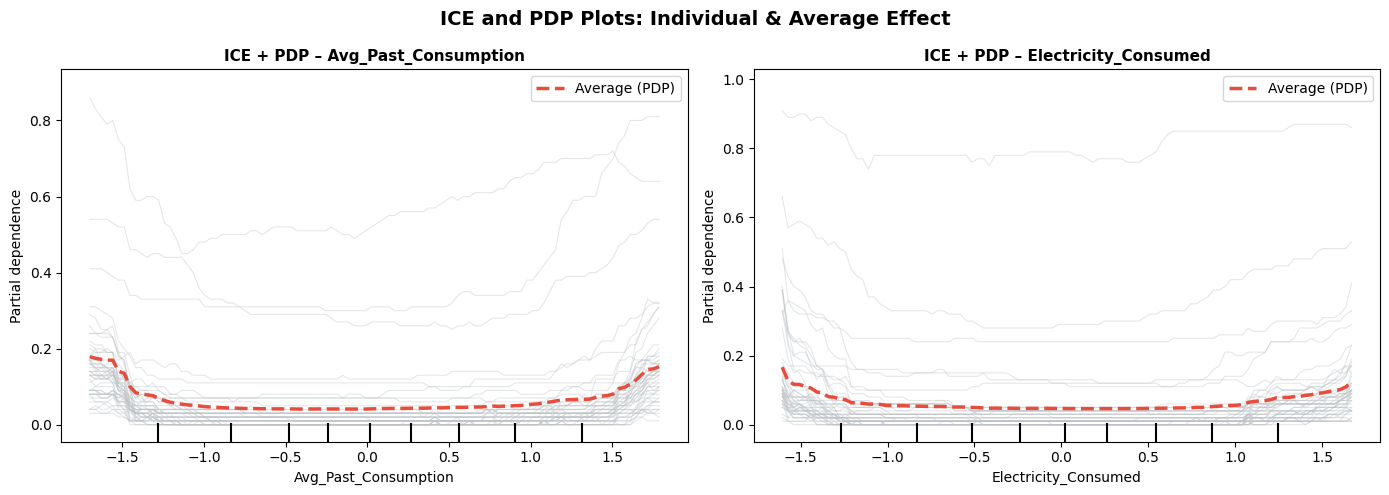

ICE: Each grey line = one test sample | Red line = average effect (PDP)


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top_features[:2]):
    feat_idx = list(X.columns).index(feat)
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test_scaled_df,
        features=[feat_idx],
        feature_names=list(X.columns),
        kind="both",            # ICE + PDP
        subsample=50,
        ax=axes[i],
        ice_lines_kw={"color": "#bdc3c7", "alpha": 0.4, "linewidth": 0.8},
        pd_line_kw={"color": "#e74c3c", "linewidth": 2.5, "label": "Average (PDP)"},
    )
    axes[i].set_title(f"ICE + PDP – {feat}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Anomaly Probability")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.suptitle("ICE and PDP Plots: Individual & Average Effect", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("ice_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("ICE: Each grey line = one test sample | Red line = average effect (PDP)")



In [59]:
!pip install dice-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 20.4 MB/s eta 0:00:0000:0100:01


In [60]:
import dice_ml
from dice_ml import Dice

#Prepare DiCE data
X_train_df = pd.DataFrame(X_train_resampled, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)
y_train_arr = np.array(y_train_resampled) if hasattr(y_train_resampled, '__len__') else y_train_resampled

# Build combined train DF with target
train_dice_df = X_train_df.copy()
train_dice_df["Anomaly"] = np.array(y_train_resampled)


dice_data = dice_ml.Data(
    dataframe=train_dice_df,
    continuous_features=list(X.columns),
    outcome_name="Anomaly"
)

dice_model = dice_ml.Model(model=rf, backend="sklearn")
dice_exp    = Dice(dice_data, dice_model, method="random")

In [61]:
#Generate counterfactuals for one ANOMALY instance
anomaly_sample = X_test_df.iloc[[anomaly_idx]]
print(f"\nGenerating counterfactuals for anomaly instance {anomaly_idx}...")
print(f"Original prediction: {rf.predict(X_test_scaled[anomaly_idx:anomaly_idx+1])[0]} (1=Anomaly)")

cf_result = dice_exp.generate_counterfactuals(
    anomaly_sample,
    total_CFs=5,
    desired_class="opposite",   # flip from Anomaly to Normal
    verbose=False
)

cf_df = cf_result.cf_examples_list[0].final_cfs_df
print("\nCounterfactual examples (changes needed to become Normal):")
print(cf_df.to_string(index=False))

# Visualize counterfactual feature changes
original_vals = anomaly_sample.values[0]
cf_vals       = cf_df.drop(columns=["Anomaly"]).values

delta_df = pd.DataFrame(
    cf_vals - original_vals,
    columns=X.columns
)


Generating counterfactuals for anomaly instance 4...
Original prediction: 1 (1=Anomaly)


100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


Counterfactual examples (changes needed to become Normal):
 Electricity_Consumed  Temperature  Humidity  Wind_Speed  Avg_Past_Consumption      hour      day   weekday     month  Monthly_Mean  Monthly_STD  Day_Part_Late_Night  Day_Part_Morning  Day_Part_Night  Anomaly
            -2.115377    -1.782918 -0.865511   -0.745932              0.713715 -0.508531 0.498924  0.515426 -1.217874      1.102949    -0.371891             -0.57735          1.741338       -0.583124        0
            -1.901353    -2.389317 -0.865511   -0.745932              0.713715  0.919211 0.498924  0.515426 -1.217874      1.102949    -0.371891             -0.57735          1.741338       -0.583124        0
             1.455492    -2.389317 -0.865511   -0.745932              0.713715 -0.508531 0.498924 -1.047252 -1.217874      1.102949    -0.371891             -0.57735          1.741338       -0.583124        0
             0.199552    -2.389317 -0.865511   -0.745932              0.713715 -0.508531 0.498924  0.515

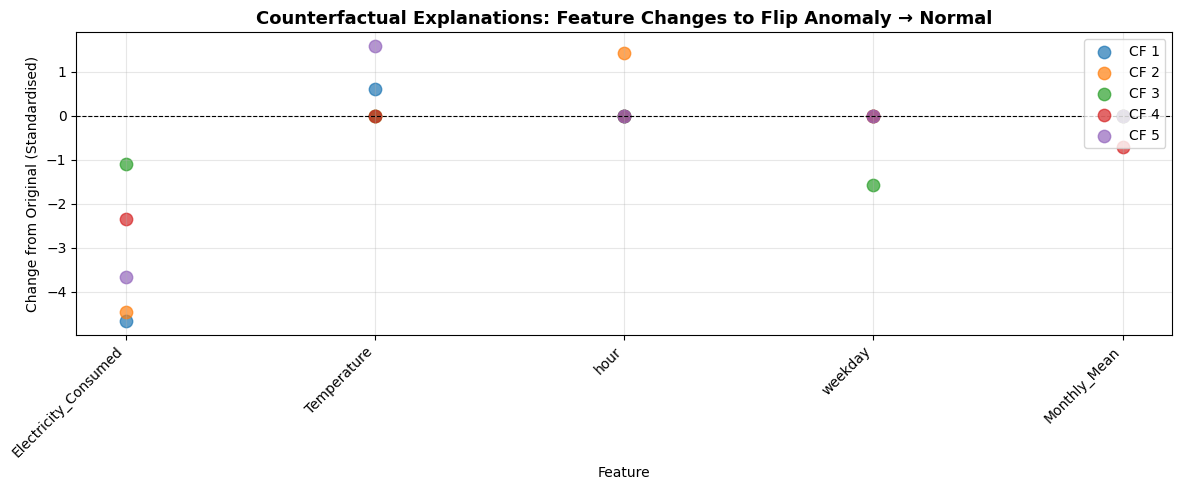

In [62]:
# Keep only features that actually changed
changed_cols = delta_df.columns[(delta_df.abs() > 0.01).any()]
delta_plot   = delta_df[changed_cols]

plt.figure(figsize=(12, 5))
for i, row in delta_plot.iterrows():
    plt.scatter(row.index, row.values, label=f"CF {i+1}", alpha=0.7, s=80)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Counterfactual Explanations: Feature Changes to Flip Anomaly → Normal", fontsize=13, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Change from Original (Standardised)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("counterfactuals.png", dpi=150, bbox_inches="tight")
plt.show()


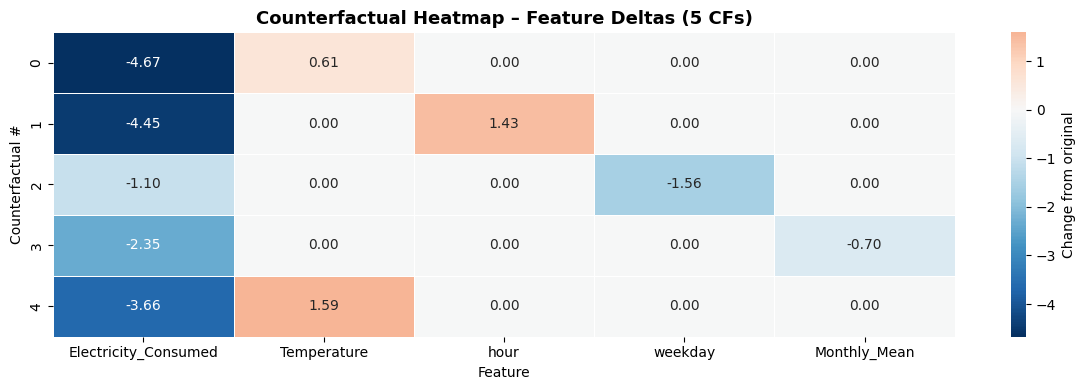


Interpretation: Blue = decrease needed | Red = increase needed to classify as Normal


In [63]:
# Heatmap of all CF changes
plt.figure(figsize=(12, 4))
sns.heatmap(
    delta_plot,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Change from original"}
)
plt.title("Counterfactual Heatmap – Feature Deltas (5 CFs)", fontsize=13, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Counterfactual #")
plt.tight_layout()
plt.savefig("counterfactual_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nInterpretation: Blue = decrease needed | Red = increase needed to classify as Normal")

XAI EVALUATION


FAITHFULNESS: Degradation as top-SHAP features removed


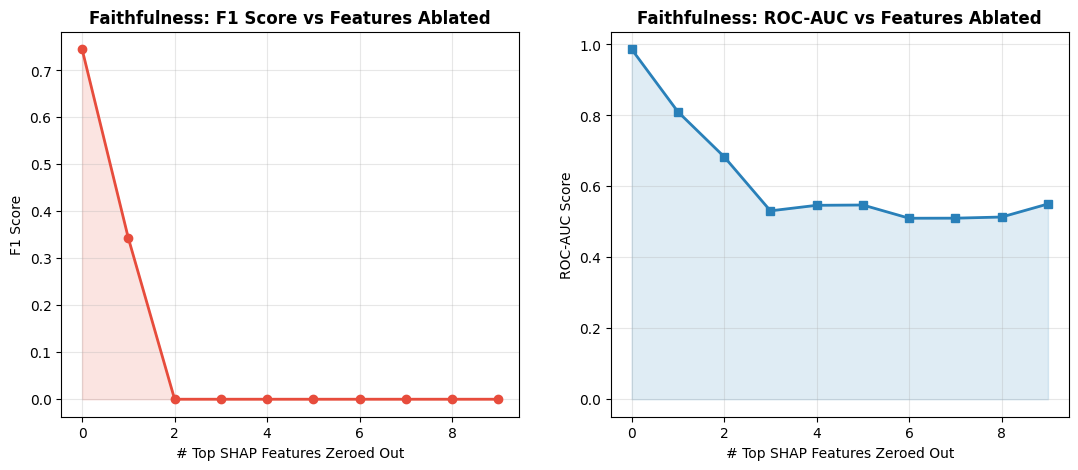

In [64]:

#4a. FAITHFULNESS TEST (Feature Ablation)
print("\nFAITHFULNESS: Degradation as top-SHAP features removed")

explainer_shap = shap.TreeExplainer(rf)
shap_values_all = explainer_shap.shap_values(X_test_scaled_df)
sv = shap_values_all[:, :, 1]

# Rank features by mean |SHAP|
mean_abs_shap = np.abs(sv).mean(axis=0)
ranked_features = np.argsort(mean_abs_shap)[::-1]   # descending

baseline_f1  = f1_score(y_test, rf.predict(X_test_scaled))
baseline_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])

f1_scores_ablation  = [baseline_f1]
auc_scores_ablation = [baseline_auc]
n_removed = [0]

X_ablated = X_test_scaled.copy()
for k in range(1, min(10, len(X.columns))):
    feat_to_zero = ranked_features[k - 1]
    X_ablated[:, feat_to_zero] = 0   # zero out most important feature
    f1_ablated  = f1_score(y_test, rf.predict(X_ablated))
    auc_ablated = roc_auc_score(y_test, rf.predict_proba(X_ablated)[:, 1])
    f1_scores_ablation.append(f1_ablated)
    auc_scores_ablation.append(auc_ablated)
    n_removed.append(k)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(n_removed, f1_scores_ablation, "o-", color="#e74c3c", linewidth=2)
axes[0].fill_between(n_removed, f1_scores_ablation, alpha=0.15, color="#e74c3c")
axes[0].set_title("Faithfulness: F1 Score vs Features Ablated", fontweight="bold")
axes[0].set_xlabel("# Top SHAP Features Zeroed Out")
axes[0].set_ylabel("F1 Score")
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_removed, auc_scores_ablation, "s-", color="#2980b9", linewidth=2)
axes[1].fill_between(n_removed, auc_scores_ablation, alpha=0.15, color="#2980b9")
axes[1].set_title("Faithfulness: ROC-AUC vs Features Ablated", fontweight="bold")
axes[1].set_xlabel("# Top SHAP Features Zeroed Out")
axes[1].set_ylabel("ROC-AUC Score")
axes[1].grid(True, alpha=0.3)



In [65]:
plt.suptitle("XAI Faithfulness Evaluation – Feature Ablation Test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

faithfulness_drop_f1  = baseline_f1 - min(f1_scores_ablation)
faithfulness_drop_auc = baseline_auc - min(auc_scores_ablation)
print(f"  Baseline F1:     {baseline_f1:.4f}")
print(f"  After ablation:  {min(f1_scores_ablation):.4f}  (drop = {faithfulness_drop_f1:.4f})")
print(f"  Faithfulness Score (AUC drop): {faithfulness_drop_auc:.4f}")
print(" Higher drop means SHAP correctly identified important features")

<Figure size 640x480 with 0 Axes>

  Baseline F1:     0.7451
  After ablation:  0.0000  (drop = 0.7451)
  Faithfulness Score (AUC drop): 0.4764
 Higher drop means SHAP correctly identified important features



STABILITY: SHAP consistency across similar instances

Top 10 features: Stability Analysis:
             Feature  Mean |SHAP|  Std SHAP  Stability Ratio
Avg_Past_Consumption     0.207978  0.184055         0.884977
Electricity_Consumed     0.173759  0.195294         1.123932
         Monthly_STD     0.030561  0.039851         1.303999
             weekday     0.028156  0.044206         1.570035
        Monthly_Mean     0.025942  0.031598         1.218020
            Humidity     0.024844  0.031814         1.280531
                hour     0.023622  0.025949         1.098525
               month     0.022974  0.024913         1.084392
          Wind_Speed     0.021336  0.025687         1.203929
         Temperature     0.015735  0.021145         1.343843


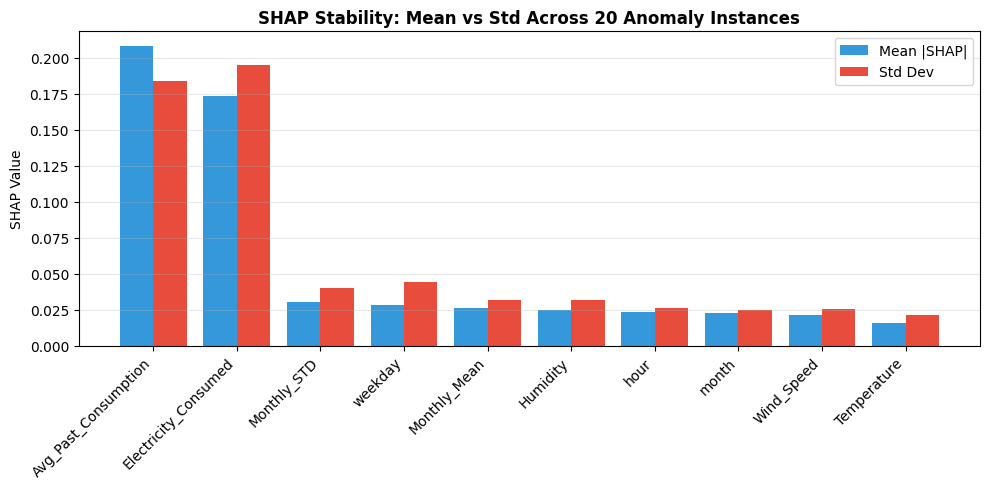

In [66]:
#4b. STABILITY TEST (SHAP)
print("\nSTABILITY: SHAP consistency across similar instances")

# Take 20 anomaly instances and measure SHAP variance
anomaly_test_indices = np.where(y_test.values == 1)[0][:20]
shap_anomaly = sv[anomaly_test_indices]

shap_std = shap_anomaly.std(axis=0)
shap_mean_abs = np.abs(shap_anomaly).mean(axis=0)

stability_df = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": shap_mean_abs,
    "Std SHAP": shap_std,
    "Stability Ratio": shap_std / (shap_mean_abs + 1e-9)
}).sort_values("Mean |SHAP|", ascending=False)

print("\nTop 10 features: Stability Analysis:")
print(stability_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top10 = stability_df.head(10)
x = np.arange(len(top10))
ax.bar(x, top10["Mean |SHAP|"], width=0.4, label="Mean |SHAP|", color="#3498db", align="center")
ax.bar(x + 0.4, top10["Std SHAP"], width=0.4, label="Std Dev", color="#e74c3c", align="center")
ax.set_xticks(x + 0.2)
ax.set_xticklabels(top10["Feature"], rotation=45, ha="right")
ax.set_title("SHAP Stability: Mean vs Std Across 20 Anomaly Instances", fontweight="bold")
ax.set_ylabel("SHAP Value")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [67]:
from scipy.stats import spearmanr

In [69]:
#AGREEMENT TEST (SHAP vs LIME vs Permutation Importance)
print("\nAGREEMENT: check if SHAP, LIME, and Permutation Importance agree")

# SHAP ranking (pre computed)
shap_ranking = pd.Series(mean_abs_shap, index=X.columns).rank(ascending=False)

# Permutation importance ranking
perm = permutation_importance(rf, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_ranking = pd.Series(perm.importances_mean, index=X.columns).rank(ascending=False)

# LIME ranking (average weights over 30 anomaly instances)
lime_anomaly_feats = {}
for idx in np.where(y_test.values == 1)[0][:30]:
    exp = lime_explainer_rf.explain_instance(
        data_row=X_test_scaled[idx],
        predict_fn=rf.predict_proba,
        num_features=len(X.columns)
    )
    for feat, wt in exp.as_list():
        lime_anomaly_feats[feat] = lime_anomaly_feats.get(feat, []) + [abs(wt)]

lime_mean_importance = {k: np.mean(v) for k, v in lime_anomaly_feats.items()}
# Map back to original column names (LIME appends condition strings)
lime_col_importance = {}
for col in X.columns:
    matched = [v for k, v in lime_mean_importance.items() if col in k]
    lime_col_importance[col] = np.mean(matched) if matched else 0.0

lime_ranking = pd.Series(lime_col_importance).rank(ascending=False)

agreement_df = pd.DataFrame({
    "SHAP Rank": shap_ranking,
    "LIME Rank": lime_ranking,
    "Permutation Rank": perm_ranking
}).dropna()

print("\nFeature Ranking Comparison (Rank 1 = most important):")
print(agreement_df.sort_values("SHAP Rank").head(10).to_string())

corr_shap_lime, _ = spearmanr(agreement_df["SHAP Rank"], agreement_df["LIME Rank"])
corr_shap_perm, _ = spearmanr(agreement_df["SHAP Rank"], agreement_df["Permutation Rank"])
corr_lime_perm, _ = spearmanr(agreement_df["LIME Rank"], agreement_df["Permutation Rank"])

print(f"\nSpearman Rank Correlation (Agreement Scores):")
print(f"  SHAP vs LIME:        {corr_shap_lime:.4f}")
print(f"  SHAP vs Permutation: {corr_shap_perm:.4f}")
print(f"  LIME vs Permutation: {corr_lime_perm:.4f}")
print("   Values closer to 1.0 have stronger agreement between XAI methods")


AGREEMENT: check if SHAP, LIME, and Permutation Importance agree

Feature Ranking Comparison (Rank 1 = most important):
                      SHAP Rank  LIME Rank  Permutation Rank
Avg_Past_Consumption        1.0        2.0               1.0
Electricity_Consumed        2.0        1.0               2.0
Monthly_STD                 3.0        5.0               4.0
Monthly_Mean                4.0        3.0               3.0
month                       5.0        4.0               5.0
weekday                     6.0        8.0               6.0
hour                        7.0       12.0               9.0
Wind_Speed                  8.0        6.0              10.0
Temperature                 9.0        9.0               7.0
day                        10.0       11.0              11.0

Spearman Rank Correlation (Agreement Scores):
  SHAP vs LIME:        0.8593
  SHAP vs Permutation: 0.9341
  LIME vs Permutation: 0.8945
   Values closer to 1.0 have stronger agreement between XAI methods


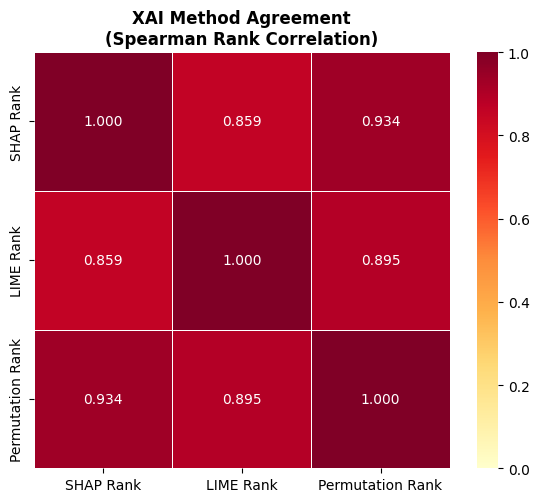

In [70]:
# Heatmap of agreement
fig, ax = plt.subplots(figsize=(6, 5))
corr_matrix = agreement_df.corr(method="spearman")
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1,
            ax=ax, linewidths=0.5, square=True)
ax.set_title("XAI Method Agreement\n(Spearman Rank Correlation)", fontweight="bold")
plt.tight_layout()
plt.savefig("xai_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

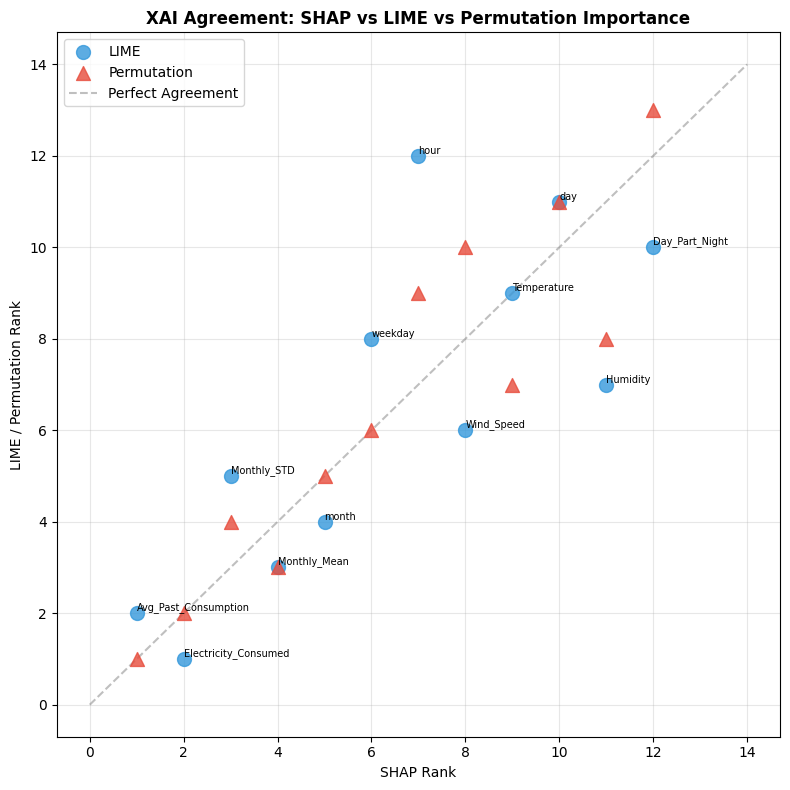

In [71]:
# Bubble chart comparison
fig, ax = plt.subplots(figsize=(8, 8))
top_n = agreement_df.sort_values("SHAP Rank").head(12)
ax.scatter(top_n["SHAP Rank"], top_n["LIME Rank"], s=100, c="#3498db", label="LIME", alpha=0.8, zorder=3)
ax.scatter(top_n["SHAP Rank"], top_n["Permutation Rank"], s=100, c="#e74c3c", marker="^", label="Permutation", alpha=0.8, zorder=3)
for feat in top_n.index:
    ax.annotate(feat, (top_n.loc[feat, "SHAP Rank"], top_n.loc[feat, "LIME Rank"]),
                fontsize=7, ha="left", va="bottom")
ax.plot([0, 14], [0, 14], "--", color="grey", alpha=0.5, label="Perfect Agreement")
ax.set_xlabel("SHAP Rank")
ax.set_ylabel("LIME / Permutation Rank")
ax.set_title("XAI Agreement: SHAP vs LIME vs Permutation Importance", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# 4d. SUMMARY EVALUATION TABLE
print("\nXAI EVALUATION SUMMARY TABLE")
print("=" * 60)

summary = {
    "XAI Method":         ["SHAP (RF)",     "LIME (RF)",     "Permutation Imp.", "Attention Weights"],
    "Scope":              ["Global+Local",  "Local",         "Global",           "Local (sequence)"],
    "Model-Agnostic":     ["No (Tree)",     "Yes",           "Yes",              "No (BiLSTM)"],
    "Top Feature":        [
        pd.Series(mean_abs_shap, index=X.columns).idxmax(),
        max(lime_col_importance, key=lime_col_importance.get),
        pd.Series(perm.importances_mean, index=X.columns).idxmax(),
        "Timestep (sequence)"
    ],
    "Stability (Std)":    [
        f"{stability_df['Std SHAP'].mean():.4f}",
        "Computed above",
        "N/A",
        "N/A"
    ],
    "Agreement (Spearman)": [
        f"SHAP-LIME: {corr_shap_lime:.3f}",
        f"LIME-Perm: {corr_lime_perm:.3f}",
        f"SHAP-Perm: {corr_shap_perm:.3f}",
        "N/A"
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


XAI EVALUATION SUMMARY TABLE
       XAI Method            Scope Model-Agnostic          Top Feature Stability (Std) Agreement (Spearman)
        SHAP (RF)     Global+Local      No (Tree) Avg_Past_Consumption          0.0475     SHAP-LIME: 0.859
        LIME (RF)            Local            Yes Electricity_Consumed  Computed above     LIME-Perm: 0.895
 Permutation Imp.           Global            Yes Avg_Past_Consumption             N/A     SHAP-Perm: 0.934
Attention Weights Local (sequence)    No (BiLSTM)  Timestep (sequence)             N/A                  N/A


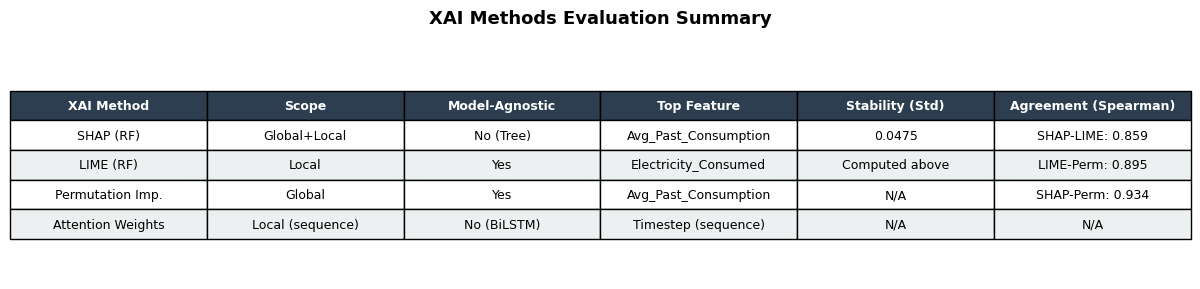

In [73]:
# Final visual summary
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#ecf0f1")
plt.title("XAI Methods Evaluation Summary", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()
